# 05_ML_Model_Comparison_Dispersion
Comprehensive ML workflow: SVR, ANN, Random Forest, Gradient Boosting

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from joblib import load
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 🔹 Import custom models
from ml.models import get_svr, get_ann, get_rf, get_gbr

# Initializing the Model

In [3]:
models = {
    "SVR": get_svr(),
    "ANN": get_ann(),
    "Random Forest": get_rf(),
    "Gradient Boosting": get_gbr()
}

# Load Data

In [4]:
ROOT = os.path.abspath("..")

# Load model and data with basic checks
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_full_dataset.xlsx')

if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found: {data_path}')

data = pd.read_excel(data_path)

# Inputs
X = data[["kL", "L", "alpha1", "s", "P1", "P2"]].values

# Output (IMPORTANT)
if 'c_beta' not in data.columns:
    raise KeyError("Column 'c_beta' not found in data")
y = data["c_beta"].values

print(f"Data shape: {X.shape}")


Data shape: (31047, 6)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model Evaluation (MAE, RMSE, R², Adjusted R²)

In [6]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    n = X_test.shape[0]
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    results.append([name, mae, rmse, r2, adj_r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "Adj_R2"])
df_results

Training SVR...
Training ANN...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2,Adj_R2
0,SVR,0.005816,0.006589,0.996457,0.996453
1,ANN,0.006517,0.008651,0.993892,0.993886
2,Random Forest,0.000207,0.000312,0.999992,0.999992
3,Gradient Boosting,0.004157,0.005540,0.997494,0.997492


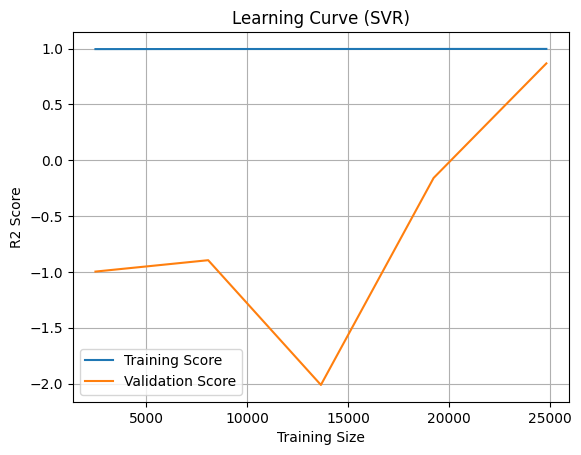

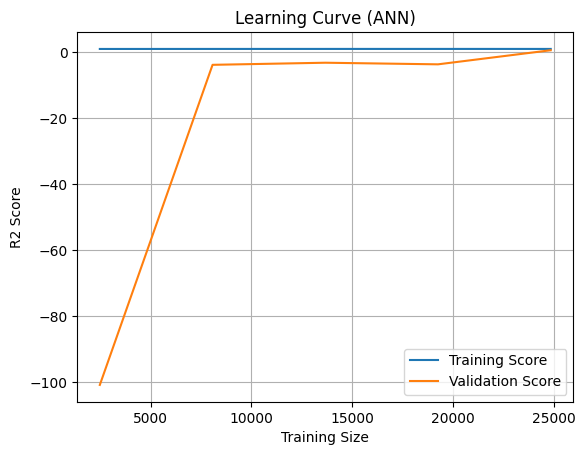

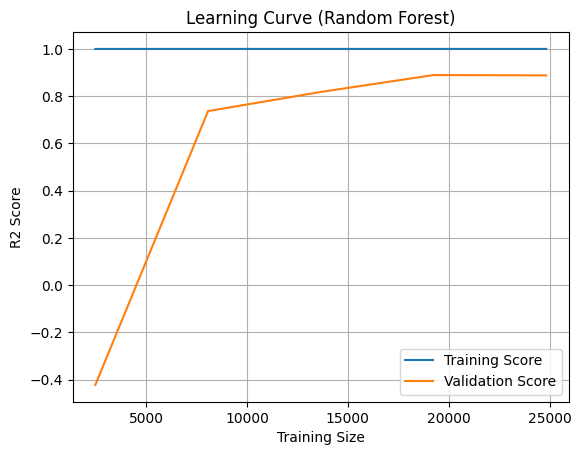

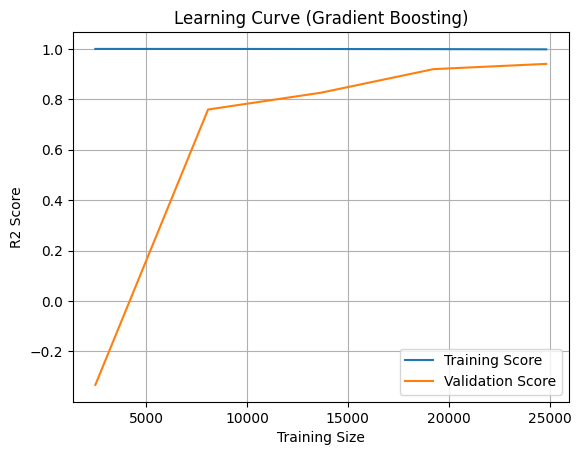

In [7]:
for name, model in models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Training Size")
    plt.ylabel("R2 Score")
    plt.legend()
    plt.grid()

    plt.show()

# Feature Importance

## RF Importance

In [8]:
rf_model = models["Random Forest"]

try:
    feature_names = X.columns
except:
    feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

rf_importance = rf_model.feature_importances_

df_rf = pd.DataFrame({
    "Feature": feature_names,
    "RF Importance": rf_importance
})

df_rf = df_rf.sort_values(by="RF Importance", ascending=False)
df_rf["RF Importance"] /= df_rf["RF Importance"].sum()
df_rf["RF Cumulative"] = df_rf["RF Importance"].cumsum()

df_rf

,Feature,RF Importance,RF Cumulative
0,Feature_0,0.465983,0.465983
3,Feature_3,0.407026,0.873009
1,Feature_1,0.077214,0.950223
2,Feature_2,0.042394,0.992617
4,Feature_4,0.007378,0.999996
5,Feature_5,0.000004,1.000000


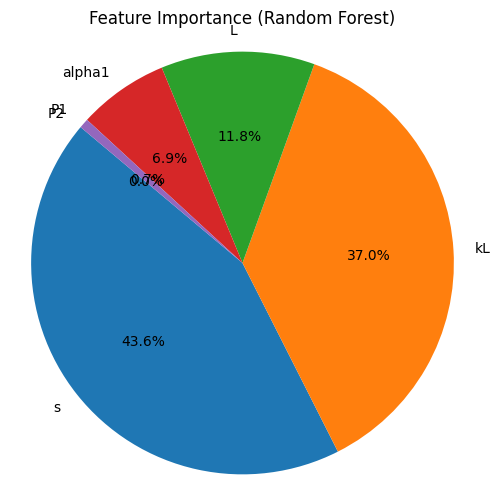

In [9]:
import matplotlib.pyplot as plt

# Feature names (your actual parameters)
labels = ["s", "kL", "L", "alpha1", "P1", "P2"]

# Importance values (your results)
importance = [0.435633, 0.370299, 0.117576, 0.069187, 0.007302, 0.000004]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(importance, labels=labels, autopct='%1.1f%%', startangle=140)

plt.title("Feature Importance (Random Forest)")
plt.axis('equal')  # ensures circle

plt.show()

## SHAP Importance for RF

In [10]:
# explainer = shap.TreeExplainer(rf_model)
# shap_values = explainer.shap_values(X)

# shap_importance = np.abs(shap_values).mean(axis=0)

# df_shap = pd.DataFrame({
#     "Feature": feature_names,
#     "SHAP Importance": shap_importance
# })

# df_shap = df_shap.sort_values(by="SHAP Importance", ascending=False)
# df_shap["SHAP Importance"] /= df_shap["SHAP Importance"].sum()
# df_shap["SHAP Cumulative"] = df_shap["SHAP Importance"].cumsum()

# df_shap

## Combined Table

In [11]:
# df_final = pd.merge(df_rf, df_shap, on="Feature")
# df_final = df_final.sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

# df_final

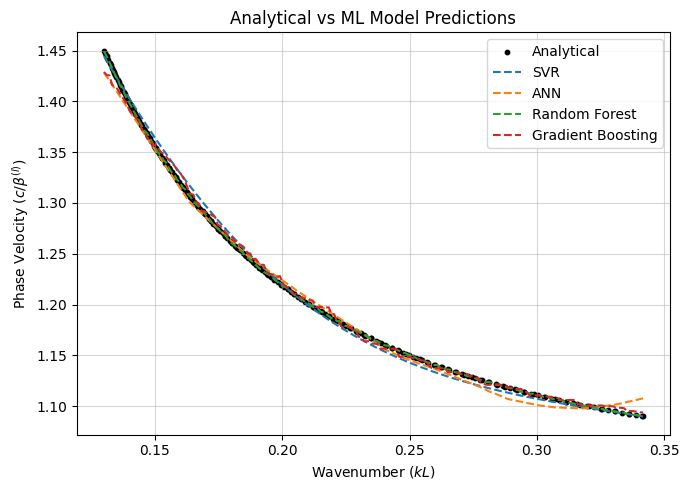

In [12]:
# Load data
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_full_dataset.xlsx')
df = pd.read_excel(data_path)

# 🔹 Fixed parameter set
L_val = 3
alpha1_val = 0.3
s_val = 100
P1_val = 1e9
P2_val = 1e9

# 🔹 Analytical data
df_plot = df[
    (df["L"] == L_val) &
    (df["alpha1"] == alpha1_val) &
    (df["s"] == s_val) &
    (df["P1"] == P1_val) &
    (df["P2"] == P2_val)
]

df_plot = df_plot.sort_values(by="kL")

# 🔹 kL range for smooth ML curves
kL_range = np.linspace(df_plot["kL"].min(), df_plot["kL"].max(), 200)

# 🔹 Input for ML models
X_curve = np.column_stack([
    kL_range,
    np.full_like(kL_range, L_val),
    np.full_like(kL_range, alpha1_val),
    np.full_like(kL_range, s_val),
    np.full_like(kL_range, P1_val),
    np.full_like(kL_range, P2_val)
])

# ==============================
# 🔸 Plot
# ==============================
plt.figure(figsize=(7,5))

# 🔹 Analytical (reference)
plt.scatter(
    df_plot["kL"],
    df_plot["c_beta"],
    color='black',
    s=10,
    label="Analytical"
)

# 🔹 ML Models (loop)
for name, model in models.items():
    y_pred = model.predict(X_curve)

    plt.plot(
        kL_range,
        y_pred,
        linewidth=1.5,
        linestyle='--',
        label=f"{name}"
    )

# Labels
plt.xlabel(r"Wavenumber ($kL$)")
plt.ylabel(r"Phase Velocity ($c/\beta^{(l)}$)")

plt.title("Analytical vs ML Model Predictions")

plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()

plt.show()

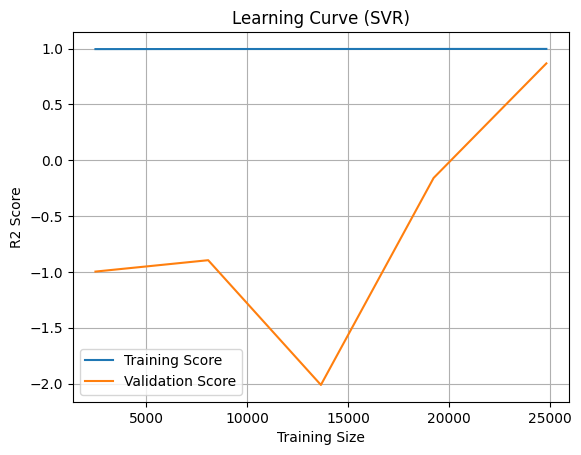

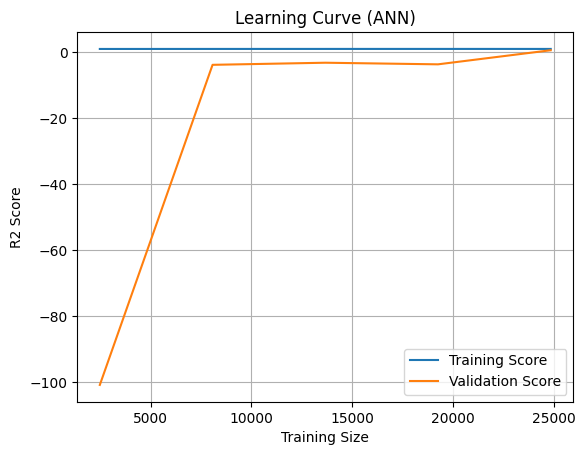

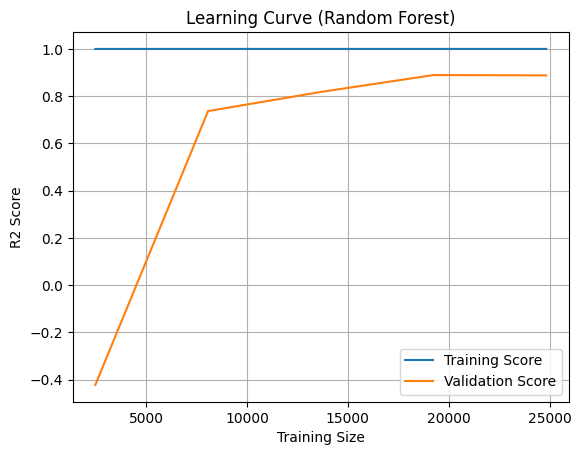

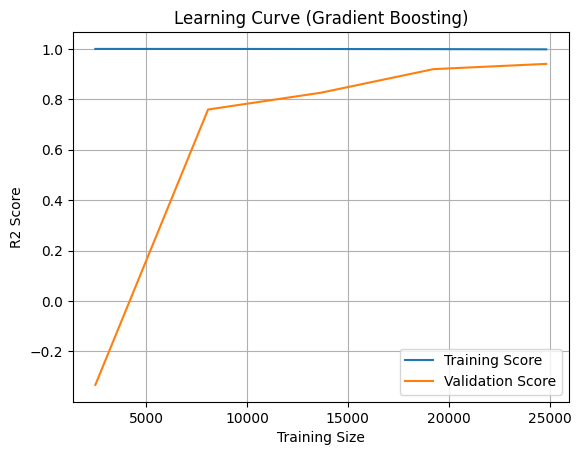

In [13]:
for name, model in models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Score")
    plt.plot(train_sizes, val_mean, label="Validation Score")

    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Training Size")
    plt.ylabel("R2 Score")

    
    plt.legend()
    plt.grid()
    plt.show()